<a href="https://colab.research.google.com/github/parthsharmaww-ai/Stock-Direction-Predictor/blob/main/notebooks/05_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 5 — Evaluation & Analysis

In this notebook we:
1. Reload models and predictions from Stage 4
2. Do a deep evaluation of results
3. Discuss why models underperformed
4. Compare against baseline honestly
5. Draw conclusions for the paper

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve,
                             roc_auc_score)
from xgboost import XGBClassifier

print("All imports successful ✓")

All imports successful ✓


In [2]:
url = "https://raw.githubusercontent.com/parthsharmaww-ai/Stock-Direction-Predictor/main/data/nifty50_features.csv"
df = pd.read_csv(url, parse_dates=["Date"])

feature_cols = ["MA5", "MA20", "MA_Signal", "Daily_Return",
                "Volatility5", "RSI14", "Volume_Change", "DayOfWeek"]
target_col = "Target"

# Time-based split
train = df[df["Date"] < "2023-01-01"]
test  = df[df["Date"] >= "2023-01-01"]

X_train = train[feature_cols].replace([np.inf, -np.inf], np.nan).dropna()
X_test  = test[feature_cols].replace([np.inf, -np.inf], np.nan).dropna()
y_train = train[target_col].loc[X_train.index]
y_test  = test[target_col].loc[X_test.index]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Retrain all 3 models
lr  = LogisticRegression(random_state=42)
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric="logloss", verbosity=0)

lr.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

lr_preds  = lr.predict(X_test_scaled)
rf_preds  = rf.predict(X_test)
xgb_preds = xgb.predict(X_test)

print("Models retrained ✓")

Models retrained ✓


## Evaluation metrics explained

- Accuracy: overall % correct predictions
- Precision: of all "up" predictions, how many were actually up?
- Recall: of all actual "up" days, how many did we catch?
- F1 Score: balance between precision and recall
- AUC-ROC: how well the model separates up vs down days
  (0.5 = random, 1.0 = perfect)

In [3]:
models = {
    "Logistic Regression": (lr_preds, lr.predict_proba(X_test_scaled)[:, 1]),
    "Random Forest":       (rf_preds, rf.predict_proba(X_test)[:, 1]),
    "XGBoost":             (xgb_preds, xgb.predict_proba(X_test)[:, 1])
}

os.makedirs("reports", exist_ok=True)

for name, (preds, proba) in models.items():
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  AUC-ROC  : {auc:.4f}")
    print(f"\n{classification_report(y_test, preds)}")


  Logistic Regression
  Accuracy : 51.55%
  AUC-ROC  : 0.5152

              precision    recall  f1-score   support

           0       0.46      0.70      0.56       211
           1       0.62      0.37      0.46       272

    accuracy                           0.52       483
   macro avg       0.54      0.54      0.51       483
weighted avg       0.55      0.52      0.50       483


  Random Forest
  Accuracy : 52.59%
  AUC-ROC  : 0.5355

              precision    recall  f1-score   support

           0       0.48      0.83      0.61       211
           1       0.69      0.29      0.41       272

    accuracy                           0.53       483
   macro avg       0.58      0.56      0.51       483
weighted avg       0.60      0.53      0.49       483


  XGBoost
  Accuracy : 50.93%
  AUC-ROC  : 0.5371

              precision    recall  f1-score   support

           0       0.46      0.72      0.56       211
           1       0.61      0.35      0.44       272

    accu

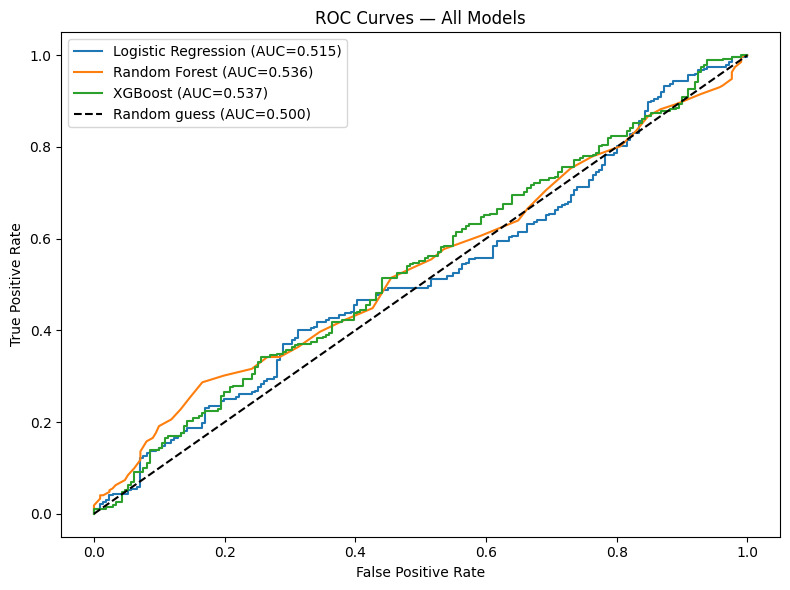

ROC curves saved ✓


In [4]:
plt.figure(figsize=(8, 6))

for name, (preds, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Random guess (AUC=0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.tight_layout()
plt.savefig("reports/roc_curves.png", dpi=150)
plt.show()
print("ROC curves saved ✓")

In [5]:
print("Prediction distributions on test set:\n")
for name, (preds, _) in models.items():
    up   = preds.sum()
    down = len(preds) - up
    print(f"{name}:")
    print(f"  Predicted Up:   {up} ({up/len(preds)*100:.1f}%)")
    print(f"  Predicted Down: {down} ({down/len(preds)*100:.1f}%)")
    print()

print(f"Actual distribution:")
print(f"  Actual Up:   {y_test.sum()} ({y_test.sum()/len(y_test)*100:.1f}%)")
print(f"  Actual Down: {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")

Prediction distributions on test set:

Logistic Regression:
  Predicted Up:   164 (34.0%)
  Predicted Down: 319 (66.0%)

Random Forest:
  Predicted Up:   113 (23.4%)
  Predicted Down: 370 (76.6%)

XGBoost:
  Predicted Up:   153 (31.7%)
  Predicted Down: 330 (68.3%)

Actual distribution:
  Actual Up:   272 (56.3%)
  Actual Down: 211 (43.7%)


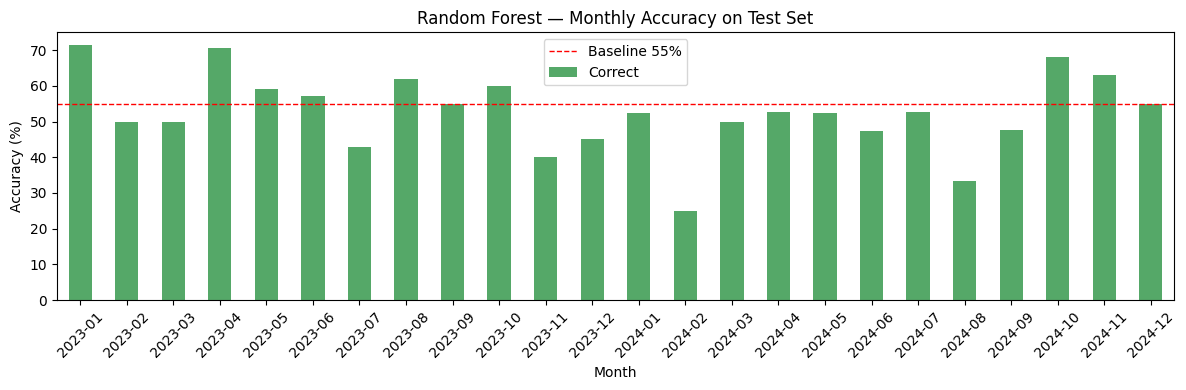

In [6]:
# Add predictions to test dataframe
test_eval = test.loc[X_test.index].copy()
test_eval["RF_Pred"] = rf_preds
test_eval["Correct"] = (test_eval["RF_Pred"] == test_eval["Target"]).astype(int)
test_eval["Month"]   = test_eval["Date"].dt.to_period("M")

monthly = test_eval.groupby("Month")["Correct"].mean() * 100

plt.figure(figsize=(12, 4))
monthly.plot(kind="bar", color="#55a868")
plt.axhline(y=55, color="red", linestyle="--", linewidth=1, label="Baseline 55%")
plt.title("Random Forest — Monthly Accuracy on Test Set")
plt.ylabel("Accuracy (%)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("reports/monthly_accuracy.png", dpi=150)
plt.show()

## Discussion

### Why did the models underperform the baseline?

1. Market efficiency
   The Nifty 50 is a large-cap index — one of the most
   efficient markets in India. Publicly available technical
   indicators are already priced in by algorithmic traders.

2. Test period characteristics
   2023–2024 was a strong bull market for Nifty 50.
   In a trending market, the naive "always predict up"
   strategy naturally performs well, making it harder
   to beat.

3. Feature limitations
   Our features are all derived from price and volume alone.
   No sentiment, macroeconomic, or fundamental data was used.

4. Model limitations
   Tree-based models can overfit to training patterns that
   don't generalise to unseen market regimes.

### What this tells us
These results support the weak form of the Efficient Market
Hypothesis — that past price data alone is insufficient to
consistently predict future price direction on the Nifty 50.

### What could improve results
- Adding sentiment indicators (news, social media)
- Using macroeconomic features (interest rates, inflation)
- Predicting over longer horizons (weekly instead of daily)
- Using deep learning models (LSTM, Transformer)

## Discussion

### Why did the models underperform the baseline?

1. Market efficiency
   The Nifty 50 is a large-cap index — one of the most
   efficient markets in India. Publicly available technical
   indicators are already priced in by algorithmic traders.

2. Test period characteristics
   2023–2024 was a strong bull market for Nifty 50.
   In a trending market, the naive "always predict up"
   strategy naturally performs well, making it harder
   to beat.

3. Feature limitations
   Our features are all derived from price and volume alone.
   No sentiment, macroeconomic, or fundamental data was used.

4. Model limitations
   Tree-based models can overfit to training patterns that
   don't generalise to unseen market regimes.

### What this tells us
These results support the weak form of the Efficient Market
Hypothesis — that past price data alone is insufficient to
consistently predict future price direction on the Nifty 50.

### What could improve results
- Adding sentiment indicators (news, social media)
- Using macroeconomic features (interest rates, inflation)
- Predicting over longer horizons (weekly instead of daily)
- Using deep learning models (LSTM, Transformer)